In [77]:
import os
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np

from energy.data import SeasonalWeekKFold, SeasonalWeekSplitter

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

import pvlib

In [6]:
#pip install duckdb
#pip install pvlib

In [196]:
day_ahead_pv = '../data/features/day_ahead_pv/day_ahead_pv_2024.parquet'
day_ahead_pv = pd.read_parquet(day_ahead_pv)
day_ahead_pv = day_ahead_pv[(day_ahead_pv.hour_local > 7) & (day_ahead_pv.hour_local < 19)]


oracle_pv = '../data/features/oracle_pv/oracle_pv_2024.parquet'
oracle_pv = pd.read_parquet(oracle_pv)
oracle_pv = oracle_pv[(oracle_pv.hour_local > 7) & (oracle_pv.hour_local < 19)]

In [197]:
add_forecast_features = ['horizon_hours']

base_features = ['hour_local', 'day_of_year', 'month', 'hour_sin',
                 'hour_cos', 'day_of_year_sin', 'day_of_year_cos']

oracle_actual_features = ['weather_actual_temperature_2m',
       'weather_actual_shortwave_radiation', 'weather_actual_direct_radiation',
       'weather_actual_diffuse_radiation', 'weather_actual_wind_speed_10m',
       'weather_actual_cloud_cover']

oracle_proxy_features = ['weather_forecast_temperature_2m',
       'weather_forecast_shortwave_radiation',
       'weather_forecast_direct_radiation',
       'weather_forecast_diffuse_radiation', 'weather_forecast_wind_speed_10m',
       'weather_forecast_cloud_cover']

oracle_features = {'actual': base_features + oracle_actual_features,
                   'proxy': base_features + oracle_proxy_features}

#pd.DataFrame([oracle_features['actual'], oracle_features['forecast']]).T

In [198]:
set(features) == set(oracle_features['actual'])

True

In [78]:
import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from energy.data import SeasonalWeekKFold


root = "../"
frame = pd.read_parquet(
    f"{root}/data/features/oracle_pv/oracle_pv_2024.parquet"
)

frame = frame.loc[
    #frame["hour_local"].between(8, 18, inclusive="both")
    frame["hour_local"].between(6, 21, inclusive="both")
].copy().reset_index(drop=True)


location = pvlib.location.Location(
    latitude=48.89,
    longitude=8.70,
    tz="Europe/Berlin",
)

times = pd.DatetimeIndex(frame["valid_time_utc"])
solar_position = location.get_solarposition(times)
clear_sky = location.get_clearsky(times, model="ineichen")


frame["solar_elevation_deg"] = solar_position["apparent_elevation"].to_numpy()
frame["solar_azimuth_deg"] = solar_position["azimuth"].to_numpy()
frame["clear_sky_ghi_w_m2"] = clear_sky["ghi"].to_numpy()

frame["actual_clear_sky_index"] = (
    frame["weather_actual_shortwave_radiation"] / frame["clear_sky_ghi_w_m2"]
)


m = 'forecast'
m = 'actual'

f = f"weather_{m}_shortwave_radiation"

MISSING_RATIO = -999.0
MIN_CLEAR_SKY_GHI = 25 #50.0  # W / m²

clear_sky_ghi = frame["clear_sky_ghi_w_m2"].to_numpy()
forecast_ghi = frame[f].to_numpy()

valid_clear_sky = clear_sky_ghi >= MIN_CLEAR_SKY_GHI

clear_sky_index = np.full(len(frame), MISSING_RATIO)

np.divide(
    forecast_ghi,
    clear_sky_ghi,
    out=clear_sky_index,
    where=valid_clear_sky,
)

frame[f"{m}_clear_sky_index"] = clear_sky_index
frame[f"{m}_clear_sky_index_valid"] = valid_clear_sky.astype("int8")


features = [
    "hour_local",
    #"day_of_year",
    #"month",
    "hour_sin",
    #"hour_cos",
    "day_of_year_sin",
    #"day_of_year_cos",
    "weather_actual_temperature_2m",
    "weather_actual_shortwave_radiation",
    "weather_actual_direct_radiation",
    "weather_actual_diffuse_radiation",
    "weather_actual_wind_speed_10m",
    "weather_actual_cloud_cover",
    
    "solar_elevation_deg",
    "solar_azimuth_deg",
    "clear_sky_ghi_w_m2",

    f"{m}_clear_sky_index",
    f"{m}_clear_sky_index_valid"
]

configs = {
    "flexible_hgb": lambda: HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=1,
        random_state=42,
    ),
    "regularized_hgb": lambda: HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=8,
        min_samples_leaf=100,
        l2_regularization=20,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=42,
    ),
    "ridge": lambda: make_pipeline(
        StandardScaler(),
        Ridge(alpha=20),
    ),
}

rows = []

for model_name, factory in configs.items():
    cv = SeasonalWeekKFold(n_splits=3, random_state=42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(frame)):
        train = frame.iloc[train_idx]
        test = frame.iloc[test_idx]

        model = factory()
        model.fit(train[features], train["pv_power_mean_w"])

        for split_name, part in [("train", train), ("test", test)]:
            prediction = np.maximum(model.predict(part[features]), 0)

            rows.append(
                {
                    "model": model_name,
                    "fold": fold,
                    "split": split_name,
                    "mae_w": mean_absolute_error(
                        part["pv_power_mean_w"], prediction
                    ),
                    "rmse_w": mean_squared_error(
                        part["pv_power_mean_w"], prediction
                    ) ** 0.5,
                }
            )

result = pd.DataFrame(rows)

summary = (
    result.groupby(["model", "split"])[["mae_w", "rmse_w"]]
    .mean()
    .round(2)
)

print(summary)

                       mae_w  rmse_w
model           split               
flexible_hgb    test   27.72   53.59
                train  10.44   18.67
regularized_hgb test   27.30   51.38
                train  22.33   42.63
ridge           test   45.80   69.96
                train  45.54   69.68


In [ ]:
                       mae_w  rmse_w
model           split               
flexible_hgb    test   27.72   53.59
                train  10.44   18.67
regularized_hgb test   27.30   51.38
                train  22.33   42.63
ridge           test   45.80   69.96
                train  45.54   69.68

In [79]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


configs = {
    "catboost": lambda: CatBoostRegressor(
        loss_function="RMSE",
        iterations=3000,
        learning_rate=0.05,
        random_seed=42,
        early_stopping_rounds=100,
        use_best_model=True,
        verbose=False,
    ),
    "lightgbm": lambda: LGBMRegressor(
        objective="regression_l2",
        n_estimators=3000,
        learning_rate=0.05,
        num_leaves=15,
        min_child_samples=10,
        random_state=42,
        verbosity=-1,
    ),
    "ridge": lambda: make_pipeline(
        StandardScaler(),
        Ridge(alpha=20),
    ),
}


rows = []

for model_name, factory in configs.items():
    cv = SeasonalWeekKFold(n_splits=3, random_state=42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(frame)):
        train = frame.iloc[train_idx]
        test = frame.iloc[test_idx]
        X_train, y_train = train[features], train["pv_power_mean_w"]
        X_test, y_test = test[features], test["pv_power_mean_w"]
        
        model = factory()

        if model_name == "catboost":
            model.fit(
                X_train,
                y_train,
                eval_set=(X_test, y_test),
            )
            
        elif model_name == "lightgbm":
            model.fit(
                X_train,
                y_train,
                eval_set=[(X_test, y_test)],
                eval_metric="rmse",
                callbacks=[
                    early_stopping(stopping_rounds=100),
                    log_evaluation(period=100),
                ],
            )
        elif model_name == "ridge":
            model.fit(train[features], train["pv_power_mean_w"])

        for split_name, part in [("train", train), ("test", test)]:
            prediction = np.maximum(model.predict(part[features]), 0)

            rows.append(
                {
                    "model": model_name,
                    "fold": fold,
                    "split": split_name,
                    "mae_w": mean_absolute_error(
                        part["pv_power_mean_w"], prediction
                    ),
                    "rmse_w": mean_squared_error(
                        part["pv_power_mean_w"], prediction
                    ) ** 0.5,
                }
            )

result = pd.DataFrame(rows)

summary = (
    result.groupby(["model", "split"])[["mae_w", "rmse_w"]]
    .mean()
    .round(2)
)

print(summary)


Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 52.7811	valid_0's l2: 2785.85
Early stopping, best iteration is:
[61]	valid_0's rmse: 52.4881	valid_0's l2: 2755
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 49.3826	valid_0's l2: 2438.64
Early stopping, best iteration is:
[92]	valid_0's rmse: 49.2238	valid_0's l2: 2422.98
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 52.7471	valid_0's l2: 2782.25
Early stopping, best iteration is:
[60]	valid_0's rmse: 52.1398	valid_0's l2: 2718.55
                mae_w  rmse_w
model    split               
catboost test   26.09   50.36
         train  22.62   43.58
lightgbm test   27.61   51.28
         train  21.94   38.82
ridge    test   45.80   69.96
         train  45.54   69.68


In [18]:
27.82 / 534, 26.60 / 534

(0.05209737827715356, 0.049812734082397)

In [19]:
f'MAE = {26.60 / 534}, nRMSE = {50.53 / 534}'

'MAE = 0.049812734082397, nRMSE = 0.09462546816479402'

In [ ]:
                mae_w  rmse_w
model    split               
catboost test   26.09   50.36
         train  22.62   43.58
lightgbm test   27.61   51.28
         train  21.94   38.82
ridge    test   45.80   69.96
         train  45.54   69.68

In [44]:
cv = SeasonalWeekKFold(n_splits=3, random_state=42)

model = configs["catboost"]()

for fold, (train_idx, test_idx) in enumerate(cv.split(frame)):
    train = frame.iloc[train_idx]
    test = frame.iloc[test_idx]
    X_train, y_train = train[features], train["pv_power_mean_w"]
    X_test, y_test = test[features], test["pv_power_mean_w"]

    model.fit(
            X_train,
            y_train,
            eval_set=(X_test, y_test),
        )
    
pred = np.maximum(model.predict(X_test), 0)

                               feature  importance
10                   solar_azimuth_deg   37.204199
12              actual_clear_sky_index   21.153576
5      weather_actual_direct_radiation    7.748771
8           weather_actual_cloud_cover    7.646628
0                           hour_local    6.792201
9                  solar_elevation_deg    4.498235
7        weather_actual_wind_speed_10m    3.263919
2                      day_of_year_sin    2.717205
1                             hour_sin    2.449487
11                  clear_sky_ghi_w_m2    1.828842
6     weather_actual_diffuse_radiation    1.605272
3        weather_actual_temperature_2m    1.304768
4   weather_actual_shortwave_radiation    1.304338
13        actual_clear_sky_index_valid    0.482562


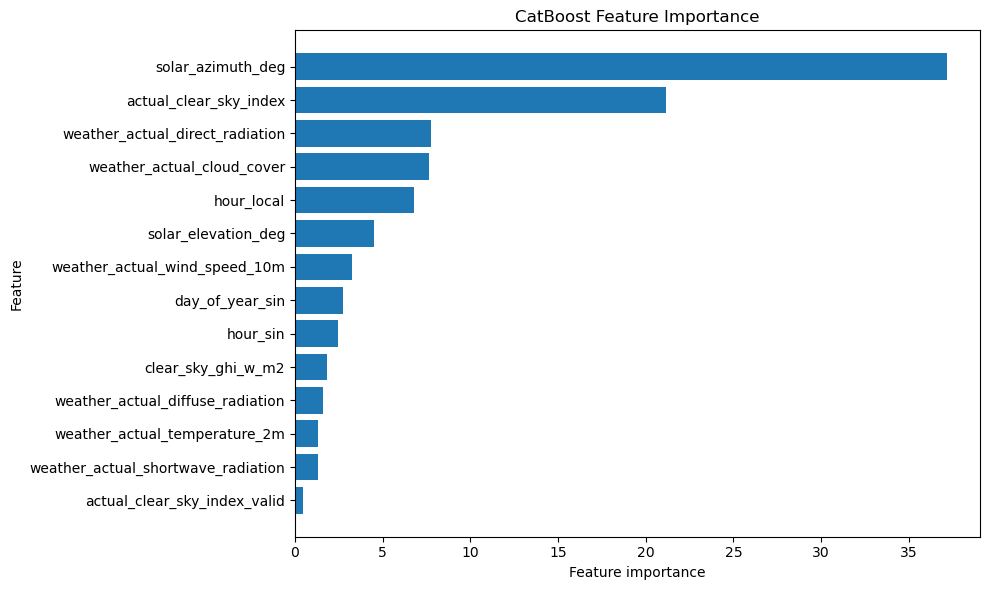

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.get_feature_importance()
}).sort_values("importance", ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1]
)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")
plt.tight_layout()
plt.show()

In [21]:
pred = np.maximum(model.predict(X_train), 0)
pd.DataFrame([y_train.values, pred], index=['fact', 'pred']).T

,fact,pred
0,0.000000,11.590884
1,0.000000,16.810322
2,8.470000,26.584794
3,26.060000,58.308235
4,396.229167,303.537538
...,...,...
3610,0.000000,0.607198
3611,0.000000,0.969453
3612,0.000000,0.714581
3613,0.000000,0.669868


In [22]:
errors['error_r'][errors['error_r']<10].hist(bins=100)

NameError: name 'errors' is not defined

In [ ]:
    f"{m}_clear_sky_index",
    f"{m}_clear_sky_index_valid"

In [25]:
X_test[f"{m}_clear_sky_index"]

255    -999.000000
256    -999.000000
257    -999.000000
258       0.203321
259       0.321727
           ...    
5258   -999.000000
5259   -999.000000
5260   -999.000000
5261   -999.000000
5262   -999.000000
Name: actual_clear_sky_index, Length: 1904, dtype: float64

In [27]:
pred = np.maximum(model.predict(X_test), 0)
errors = pd.DataFrame([y_test.values, pred], index=['fact', 'pred']).T
errors['error'] = errors['fact'] - errors['pred']
errors['error_r'] = errors['error'].map(np.abs) / errors['fact']
errors[f"{m}_clear_sky_index"] = X_test[f"{m}_clear_sky_index"].values
errors

,fact,pred,error,error_r,actual_clear_sky_index
0,0.000000,0.729422,-0.729422,inf,-999.000000
1,0.157500,1.451902,-1.294402,8.218426,-999.000000
2,57.447500,9.071436,48.376064,0.842092,-999.000000
3,217.265000,17.617358,199.647642,0.918913,0.203321
4,312.036667,37.043361,274.993306,0.881285,0.321727
...,...,...,...,...,...
1899,0.000000,0.943014,-0.943014,inf,-999.000000
1900,0.000000,0.851856,-0.851856,inf,-999.000000
1901,0.000000,0.701585,-0.701585,inf,-999.000000
1902,0.000000,0.712224,-0.712224,inf,-999.000000


<AxesSubplot: >

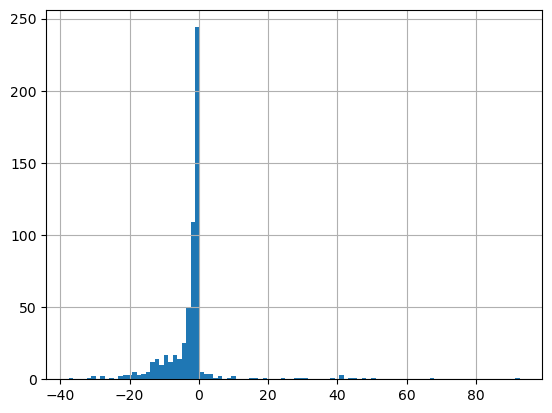

In [29]:
errors[errors['actual_clear_sky_index']==-999].error.hist(bins=100)

<AxesSubplot: xlabel='actual_clear_sky_index', ylabel='fact'>

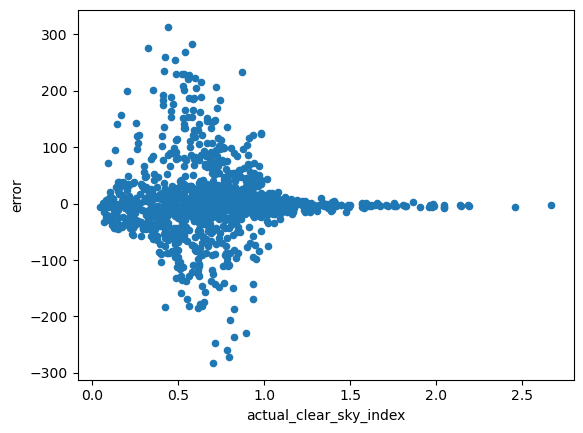

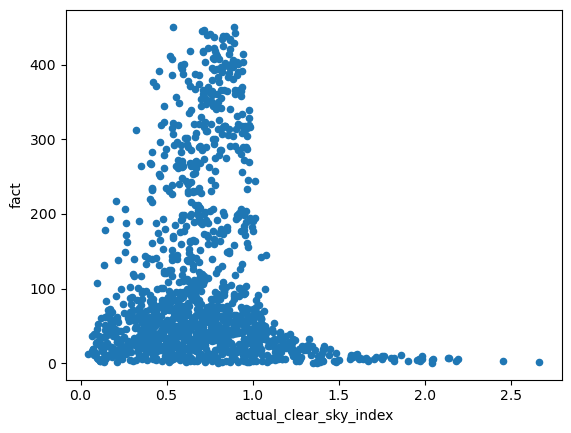

In [31]:
errors[errors['actual_clear_sky_index']!=-999].plot.scatter(x='actual_clear_sky_index', y='error')
errors[errors['actual_clear_sky_index']!=-999].plot.scatter(x='actual_clear_sky_index', y='fact')

<AxesSubplot: >

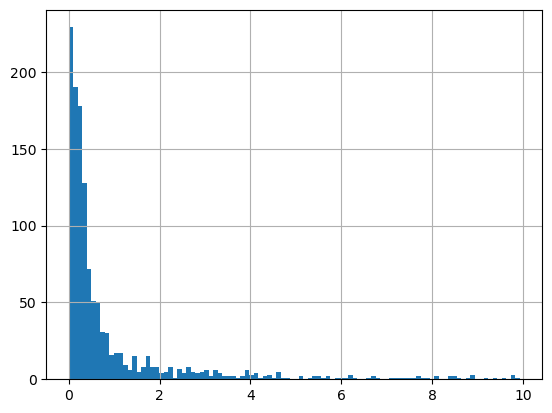

In [195]:
errors['error_r'][errors['error_r']<10].hist(bins=100)

<AxesSubplot: >

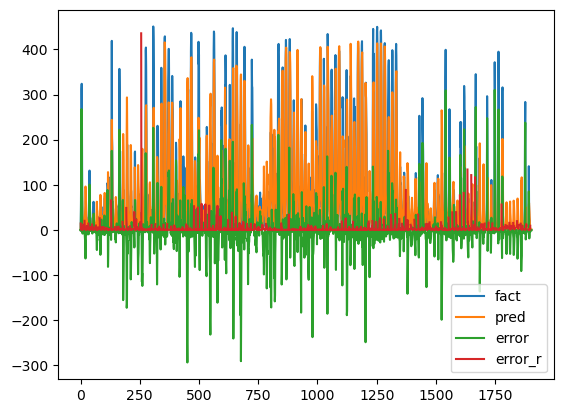

In [207]:
errors.plot()

<AxesSubplot: >

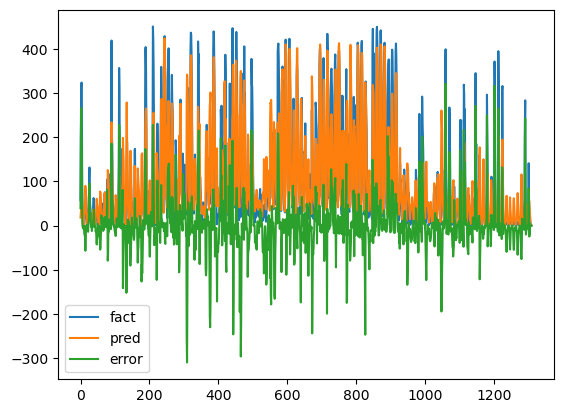

In [175]:
errors.plot()

In [187]:
test.groupby('hour_local')['pv_power_mean_w'].mean()

hour_local
8     125.335413
9     169.592157
10    197.806891
11    185.897983
12    157.226141
13    101.084272
14     59.553319
15     46.468053
16     35.568074
17     23.667899
18     15.773340
Name: pv_power_mean_w, dtype: float64

In [183]:
X_test.iloc[errors[errors['error'].map(np.abs)<50].index, :].hour_local.value_counts()

15    119
16    119
17    119
18    119
14    118
13    102
8      74
12     68
11     62
9      56
10     53
Name: hour_local, dtype: int64

In [181]:
X_test.hour_local.value_counts()

8     119
9     119
10    119
11    119
12    119
13    119
14    119
15    119
16    119
17    119
18    119
Name: hour_local, dtype: int64

In [178]:
errors[errors['error'].map(np.abs)>100].

,fact,pred,error
1,217.265000,29.285962,187.979038
2,312.036667,45.942612,266.094054
3,323.851667,101.993457,221.858210
4,239.977500,94.383721,145.593779
90,418.990000,233.573058,185.416942
...,...,...,...
1213,319.660000,203.306947,116.353053
1223,306.906667,174.957576,131.949090
1224,315.906667,194.582437,121.324229
1289,232.015833,38.493751,193.522083


In [136]:
rows = []

for model_name, factory in configs.items():
    cv = SeasonalWeekKFold(n_splits=3, random_state=42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(frame)):
        train = frame.iloc[train_idx]
        test = frame.iloc[test_idx]

        model = CatBoostRegressor(loss_function="RMSE",
                              random_seed=42,
                              use_best_model=True,
                              verbose=True
                             )
        
        model.fit(train[features], train["pv_power_mean_w"], eval_set=(test[features],
                                                                       test["pv_power_mean_w"]))

        for split_name, part in [("train", train), ("test", test)]:
            prediction = np.maximum(model.predict(part[features]), 0)

            rows.append(
                {
                    "fold": fold,
                    "split": split_name,
                    "mae_w": mean_absolute_error(
                        part["pv_power_mean_w"], prediction
                    ),
                    "rmse_w": mean_squared_error(
                        part["pv_power_mean_w"], prediction
                    ) ** 0.5,
                }
            )

result = pd.DataFrame(rows)

summary = (
    result.groupby(["split"])[["mae_w", "rmse_w"]]
    .mean()
    .round(2)
)

print(summary)

Learning rate set to 0.05903
0:	learn: 112.9708937	test: 113.3633754	best: 113.3633754 (0)	total: 2.15ms	remaining: 2.15s
1:	learn: 109.1728540	test: 109.9674698	best: 109.9674698 (1)	total: 2.95ms	remaining: 1.47s
2:	learn: 105.6424775	test: 106.5969224	best: 106.5969224 (2)	total: 3.75ms	remaining: 1.25s
3:	learn: 102.1047842	test: 103.3520624	best: 103.3520624 (3)	total: 4.61ms	remaining: 1.15s
4:	learn: 98.7068402	test: 100.2912677	best: 100.2912677 (4)	total: 5.44ms	remaining: 1.08s
5:	learn: 95.8002102	test: 97.6636133	best: 97.6636133 (5)	total: 6.61ms	remaining: 1.09s
6:	learn: 92.8945277	test: 95.1420069	best: 95.1420069 (6)	total: 7.48ms	remaining: 1.06s
7:	learn: 90.5932335	test: 93.0628088	best: 93.0628088 (7)	total: 8.37ms	remaining: 1.04s
8:	learn: 88.0640249	test: 90.9469355	best: 90.9469355 (8)	total: 9.3ms	remaining: 1.02s
9:	learn: 85.7810132	test: 88.9995579	best: 88.9995579 (9)	total: 10.3ms	remaining: 1.02s
10:	learn: 83.7503759	test: 87.2832817	best: 87.2832817 (1

220:	learn: 44.2604601	test: 65.2852243	best: 63.4015296 (91)	total: 188ms	remaining: 662ms
221:	learn: 44.2053871	test: 65.2682588	best: 63.4015296 (91)	total: 189ms	remaining: 661ms
222:	learn: 44.1815451	test: 65.2615971	best: 63.4015296 (91)	total: 190ms	remaining: 660ms
223:	learn: 44.0796413	test: 65.2632787	best: 63.4015296 (91)	total: 190ms	remaining: 659ms
224:	learn: 44.0449466	test: 65.2410766	best: 63.4015296 (91)	total: 191ms	remaining: 658ms
225:	learn: 43.9553013	test: 65.2854443	best: 63.4015296 (91)	total: 192ms	remaining: 657ms
226:	learn: 43.8705406	test: 65.3176822	best: 63.4015296 (91)	total: 193ms	remaining: 656ms
227:	learn: 43.8225198	test: 65.3371775	best: 63.4015296 (91)	total: 193ms	remaining: 654ms
228:	learn: 43.7911659	test: 65.3415799	best: 63.4015296 (91)	total: 194ms	remaining: 653ms
229:	learn: 43.7569765	test: 65.3446352	best: 63.4015296 (91)	total: 195ms	remaining: 652ms
230:	learn: 43.7052846	test: 65.3426775	best: 63.4015296 (91)	total: 195ms	remai

464:	learn: 34.3345126	test: 67.6979933	best: 63.4015296 (91)	total: 377ms	remaining: 434ms
465:	learn: 34.3030900	test: 67.6996690	best: 63.4015296 (91)	total: 378ms	remaining: 433ms
466:	learn: 34.2648344	test: 67.6951875	best: 63.4015296 (91)	total: 379ms	remaining: 432ms
467:	learn: 34.2588680	test: 67.6970556	best: 63.4015296 (91)	total: 380ms	remaining: 432ms
468:	learn: 34.2449334	test: 67.7110949	best: 63.4015296 (91)	total: 381ms	remaining: 431ms
469:	learn: 34.2220861	test: 67.7135981	best: 63.4015296 (91)	total: 381ms	remaining: 430ms
470:	learn: 34.2047064	test: 67.7206477	best: 63.4015296 (91)	total: 382ms	remaining: 429ms
471:	learn: 34.1777467	test: 67.7679396	best: 63.4015296 (91)	total: 383ms	remaining: 428ms
472:	learn: 34.1345446	test: 67.7705291	best: 63.4015296 (91)	total: 384ms	remaining: 427ms
473:	learn: 34.1152594	test: 67.7958599	best: 63.4015296 (91)	total: 384ms	remaining: 427ms
474:	learn: 34.0758130	test: 67.8045261	best: 63.4015296 (91)	total: 385ms	remai

712:	learn: 27.6705845	test: 68.6964897	best: 63.4015296 (91)	total: 567ms	remaining: 228ms
713:	learn: 27.6556885	test: 68.6983626	best: 63.4015296 (91)	total: 568ms	remaining: 227ms
714:	learn: 27.6478739	test: 68.6963521	best: 63.4015296 (91)	total: 568ms	remaining: 227ms
715:	learn: 27.6240932	test: 68.7060889	best: 63.4015296 (91)	total: 569ms	remaining: 226ms
716:	learn: 27.6013661	test: 68.6979486	best: 63.4015296 (91)	total: 570ms	remaining: 225ms
717:	learn: 27.5852619	test: 68.6862328	best: 63.4015296 (91)	total: 571ms	remaining: 224ms
718:	learn: 27.5758790	test: 68.6848327	best: 63.4015296 (91)	total: 571ms	remaining: 223ms
719:	learn: 27.5544821	test: 68.7214408	best: 63.4015296 (91)	total: 572ms	remaining: 223ms
720:	learn: 27.5212327	test: 68.7335553	best: 63.4015296 (91)	total: 573ms	remaining: 222ms
721:	learn: 27.5039802	test: 68.7393306	best: 63.4015296 (91)	total: 574ms	remaining: 221ms
722:	learn: 27.4873105	test: 68.7416997	best: 63.4015296 (91)	total: 575ms	remai

955:	learn: 23.2774865	test: 69.4445328	best: 63.4015296 (91)	total: 756ms	remaining: 34.8ms
956:	learn: 23.2669175	test: 69.4705958	best: 63.4015296 (91)	total: 757ms	remaining: 34ms
957:	learn: 23.2388033	test: 69.4665658	best: 63.4015296 (91)	total: 758ms	remaining: 33.2ms
958:	learn: 23.2356429	test: 69.4644682	best: 63.4015296 (91)	total: 759ms	remaining: 32.4ms
959:	learn: 23.2223374	test: 69.4702153	best: 63.4015296 (91)	total: 760ms	remaining: 31.7ms
960:	learn: 23.2121257	test: 69.4716476	best: 63.4015296 (91)	total: 760ms	remaining: 30.9ms
961:	learn: 23.2084536	test: 69.4720908	best: 63.4015296 (91)	total: 761ms	remaining: 30.1ms
962:	learn: 23.1956314	test: 69.4787078	best: 63.4015296 (91)	total: 762ms	remaining: 29.3ms
963:	learn: 23.1849477	test: 69.4732947	best: 63.4015296 (91)	total: 763ms	remaining: 28.5ms
964:	learn: 23.1632677	test: 69.4898779	best: 63.4015296 (91)	total: 764ms	remaining: 27.7ms
965:	learn: 23.1439731	test: 69.5072712	best: 63.4015296 (91)	total: 765

...

985:	learn: 22.4727083	test: 66.9693151	best: 58.8217881 (114)	total: 858ms	remaining: 12.2ms
986:	learn: 22.4564265	test: 66.9730407	best: 58.8217881 (114)	total: 859ms	remaining: 11.3ms
987:	learn: 22.4451539	test: 66.9718517	best: 58.8217881 (114)	total: 859ms	remaining: 10.4ms
988:	learn: 22.4328761	test: 66.9674892	best: 58.8217881 (114)	total: 860ms	remaining: 9.56ms
989:	learn: 22.4210841	test: 67.0090686	best: 58.8217881 (114)	total: 861ms	remaining: 8.7ms
990:	learn: 22.4079348	test: 67.0075989	best: 58.8217881 (114)	total: 862ms	remaining: 7.82ms
991:	learn: 22.3937130	test: 67.0062058	best: 58.8217881 (114)	total: 862ms	remaining: 6.95ms
992:	learn: 22.3814760	test: 67.0112729	best: 58.8217881 (114)	total: 863ms	remaining: 6.08ms
993:	learn: 22.3575100	test: 67.0119777	best: 58.8217881 (114)	total: 864ms	remaining: 5.21ms
994:	learn: 22.3325264	test: 67.0328768	best: 58.8217881 (114)	total: 865ms	remaining: 4.34ms
995:	learn: 22.3265761	test: 67.0456717	best: 58.8217881 (114

204:	learn: 43.5085711	test: 62.9823136	best: 61.9419194 (87)	total: 154ms	remaining: 598ms
205:	learn: 43.4564859	test: 62.9829236	best: 61.9419194 (87)	total: 155ms	remaining: 598ms
206:	learn: 43.4053613	test: 62.9847758	best: 61.9419194 (87)	total: 156ms	remaining: 597ms
207:	learn: 43.3100641	test: 63.0304802	best: 61.9419194 (87)	total: 157ms	remaining: 596ms
208:	learn: 43.2286824	test: 63.0289484	best: 61.9419194 (87)	total: 157ms	remaining: 596ms
209:	learn: 43.1850158	test: 63.0004716	best: 61.9419194 (87)	total: 158ms	remaining: 595ms
210:	learn: 43.1124504	test: 62.9698039	best: 61.9419194 (87)	total: 159ms	remaining: 594ms
211:	learn: 43.0788193	test: 63.0188985	best: 61.9419194 (87)	total: 160ms	remaining: 594ms
212:	learn: 43.0243082	test: 63.0098313	best: 61.9419194 (87)	total: 161ms	remaining: 593ms
213:	learn: 42.9365119	test: 63.0153377	best: 61.9419194 (87)	total: 161ms	remaining: 593ms
214:	learn: 42.8441461	test: 62.9811074	best: 61.9419194 (87)	total: 162ms	remai

452:	learn: 32.6140733	test: 64.5817767	best: 61.9419194 (87)	total: 344ms	remaining: 415ms
453:	learn: 32.5858753	test: 64.5855500	best: 61.9419194 (87)	total: 345ms	remaining: 415ms
454:	learn: 32.5305458	test: 64.5917826	best: 61.9419194 (87)	total: 346ms	remaining: 414ms
455:	learn: 32.4976963	test: 64.5964222	best: 61.9419194 (87)	total: 347ms	remaining: 414ms
456:	learn: 32.4686694	test: 64.5930026	best: 61.9419194 (87)	total: 347ms	remaining: 413ms
457:	learn: 32.4375982	test: 64.5964974	best: 61.9419194 (87)	total: 348ms	remaining: 412ms
458:	learn: 32.3875764	test: 64.6077073	best: 61.9419194 (87)	total: 349ms	remaining: 411ms
459:	learn: 32.3566241	test: 64.5992405	best: 61.9419194 (87)	total: 350ms	remaining: 411ms
460:	learn: 32.3301259	test: 64.5960598	best: 61.9419194 (87)	total: 351ms	remaining: 410ms
461:	learn: 32.2910447	test: 64.5917520	best: 61.9419194 (87)	total: 351ms	remaining: 409ms
462:	learn: 32.2578255	test: 64.5875973	best: 61.9419194 (87)	total: 352ms	remai

687:	learn: 26.0879342	test: 65.3753322	best: 61.9419194 (87)	total: 534ms	remaining: 242ms
688:	learn: 26.0597474	test: 65.3790915	best: 61.9419194 (87)	total: 535ms	remaining: 242ms
689:	learn: 26.0314240	test: 65.3862936	best: 61.9419194 (87)	total: 536ms	remaining: 241ms
690:	learn: 26.0002180	test: 65.3970447	best: 61.9419194 (87)	total: 537ms	remaining: 240ms
691:	learn: 25.9794583	test: 65.4030341	best: 61.9419194 (87)	total: 538ms	remaining: 239ms
692:	learn: 25.9598709	test: 65.3952009	best: 61.9419194 (87)	total: 538ms	remaining: 238ms
693:	learn: 25.9205673	test: 65.4115012	best: 61.9419194 (87)	total: 539ms	remaining: 238ms
694:	learn: 25.9038887	test: 65.4199321	best: 61.9419194 (87)	total: 540ms	remaining: 237ms
695:	learn: 25.8829556	test: 65.4106817	best: 61.9419194 (87)	total: 541ms	remaining: 236ms
696:	learn: 25.8550044	test: 65.4053625	best: 61.9419194 (87)	total: 541ms	remaining: 235ms
697:	learn: 25.8280582	test: 65.3856729	best: 61.9419194 (87)	total: 542ms	remai

885:	learn: 22.2477703	test: 65.7239301	best: 61.9419194 (87)	total: 732ms	remaining: 94.2ms
886:	learn: 22.2261222	test: 65.7264088	best: 61.9419194 (87)	total: 733ms	remaining: 93.4ms
887:	learn: 22.2061832	test: 65.7274518	best: 61.9419194 (87)	total: 735ms	remaining: 92.7ms
888:	learn: 22.1930334	test: 65.7279599	best: 61.9419194 (87)	total: 735ms	remaining: 91.8ms
889:	learn: 22.1803369	test: 65.7159598	best: 61.9419194 (87)	total: 737ms	remaining: 91ms
890:	learn: 22.1643317	test: 65.7204044	best: 61.9419194 (87)	total: 737ms	remaining: 90.2ms
891:	learn: 22.1538550	test: 65.7243860	best: 61.9419194 (87)	total: 738ms	remaining: 89.4ms
892:	learn: 22.1399740	test: 65.7301833	best: 61.9419194 (87)	total: 739ms	remaining: 88.6ms
893:	learn: 22.1260292	test: 65.7351702	best: 61.9419194 (87)	total: 741ms	remaining: 87.9ms
894:	learn: 22.1117987	test: 65.7392453	best: 61.9419194 (87)	total: 742ms	remaining: 87.1ms
895:	learn: 22.0958349	test: 65.7385870	best: 61.9419194 (87)	total: 743

In [130]:
def train_lgbm(X_train, y_train, X_test, y_test, loss="rmse"):
    """
    Train LightGBM regressor and evaluate with MAE and RMSE.
    loss: "mae" or "rmse"
    """

    objectives = {
        "mae": "regression_l1",
        "rmse": "regression_l2",
    }

    if loss not in objectives:
        raise ValueError("loss must be 'mae' or 'rmse'")

    """
    model = LGBMRegressor(
        objective=objectives[loss],
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=15,
        min_child_samples=10,
        random_state=42,
        verbosity=1,
    )
    """
    
    model = CatBoostRegressor(loss_function="RMSE",
                              random_seed=42,
                              early_stopping_rounds=100,
                              use_best_model=True,
                              verbose=True
                             )

    model.fit(X_train, y_train, eval_set=(X_test, y_test))

    y_pred = model.predict(X_test)
    metrics = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    }
    return model, metrics, y_pred

<AxesSubplot: >

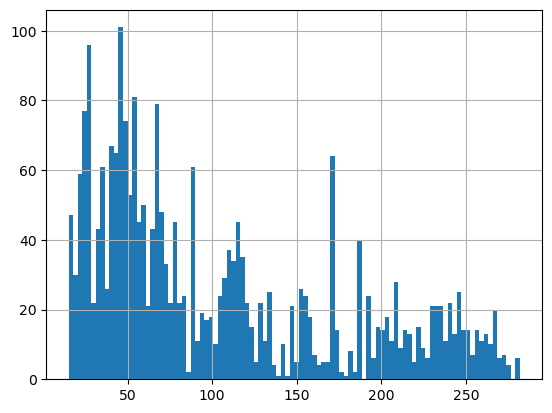

In [123]:
pd.Series(y_pred).hist(bins=100)

In [118]:
X_train

,hour_local,day_of_year,month,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos
391,8,36,2,8.660254e-01,-5.000000e-01,0.579421,0.815028
392,9,36,2,7.071068e-01,-7.071068e-01,0.579421,0.815028
393,10,36,2,5.000000e-01,-8.660254e-01,0.579421,0.815028
394,11,36,2,2.588190e-01,-9.659258e-01,0.579421,0.815028
395,12,36,2,1.224647e-16,-1.000000e+00,0.579421,0.815028
...,...,...,...,...,...,...,...
7883,14,350,12,-5.000000e-01,-8.660254e-01,-0.271234,0.962513
7884,15,350,12,-7.071068e-01,-7.071068e-01,-0.271234,0.962513
7885,16,350,12,-8.660254e-01,-5.000000e-01,-0.271234,0.962513
7886,17,350,12,-9.659258e-01,-2.588190e-01,-0.271234,0.962513


In [117]:
folds = SeasonalWeekKFold(n_splits=3, random_state=42)

for forecast_indices, oracle_indices in folds.split(day_ahead_pv):

    oracle_train, oracle_test = oracle_pv.iloc[oracle_indices], oracle_pv.iloc[forecast_indices]
    
    X_train = oracle_train.loc[:, oracle_features['actual']]
    y_train = oracle_train['pv_power_mean_w']
    X_test = oracle_test.loc[:, oracle_features['actual']]
    y_test = oracle_test['pv_power_mean_w']
    
    """
    print(y_train.describe())
    print(y_test.describe())

    print(X_train.isna().sum())
    print(X_test.isna().sum())
    """

    _, metrics, y_pred =  train_lgbm(X_train,
               y_train,
               X_test,
               y_test, loss="rmse"
                                    )
    
    #print(y_pred.min(), y_pred.max(), y_pred.mean())
    print(metrics)
    
    
    split = SeasonalWeekSplitter(random_state=42, train_size = 0.7,
                             validation_size = 0.0,
                             test_size = 0.3).split(day_ahead_pv.iloc[forecast_indices])
    forecast_train, forecast_test = split.train, split.test

Learning rate set to 0.05261
0:	learn: 114.1389074	test: 114.9109847	best: 114.9109847 (0)	total: 513us	remaining: 513ms
1:	learn: 111.4626047	test: 112.3848069	best: 112.3848069 (1)	total: 918us	remaining: 458ms
2:	learn: 108.6330158	test: 109.6768224	best: 109.6768224 (2)	total: 1.39ms	remaining: 462ms
3:	learn: 106.3807796	test: 107.4021713	best: 107.4021713 (3)	total: 1.75ms	remaining: 437ms
4:	learn: 104.2523500	test: 105.3333920	best: 105.3333920 (4)	total: 2.17ms	remaining: 432ms
5:	learn: 102.1439880	test: 103.4491846	best: 103.4491846 (5)	total: 2.57ms	remaining: 425ms
6:	learn: 100.3930512	test: 101.9700384	best: 101.9700384 (6)	total: 2.88ms	remaining: 408ms
7:	learn: 98.5590562	test: 100.5027273	best: 100.5027273 (7)	total: 3.25ms	remaining: 403ms
8:	learn: 96.7947953	test: 98.9387136	best: 98.9387136 (8)	total: 3.67ms	remaining: 404ms
9:	learn: 95.2633862	test: 97.8012157	best: 97.8012157 (9)	total: 4.06ms	remaining: 402ms
10:	learn: 93.7847236	test: 96.7010246	best: 96.70

62:	learn: 70.7293930	test: 88.7013018	best: 88.2258189 (38)	total: 27.3ms	remaining: 407ms
63:	learn: 70.6559180	test: 88.7449689	best: 88.2258189 (38)	total: 27.8ms	remaining: 407ms
64:	learn: 70.4369094	test: 88.8701350	best: 88.2258189 (38)	total: 28.3ms	remaining: 407ms
65:	learn: 70.2763513	test: 88.8941727	best: 88.2258189 (38)	total: 28.7ms	remaining: 407ms
66:	learn: 70.1771659	test: 88.9661847	best: 88.2258189 (38)	total: 29.1ms	remaining: 405ms
67:	learn: 69.9064961	test: 88.9817583	best: 88.2258189 (38)	total: 29.4ms	remaining: 404ms
68:	learn: 69.8588817	test: 88.9822371	best: 88.2258189 (38)	total: 29.9ms	remaining: 403ms
69:	learn: 69.7649005	test: 88.9765586	best: 88.2258189 (38)	total: 30.3ms	remaining: 402ms
70:	learn: 69.6513571	test: 88.9997633	best: 88.2258189 (38)	total: 30.7ms	remaining: 402ms
71:	learn: 69.5892867	test: 89.0323996	best: 88.2258189 (38)	total: 31.1ms	remaining: 401ms
72:	learn: 69.5010010	test: 89.0409046	best: 88.2258189 (38)	total: 31.5ms	remai

In [104]:
pwd

'/Users/andreichekunov/andrei/machine_learning/2026/energy/working'

In [80]:
pd.DataFrame([oracle_test['pv_power_mean_w'].values, y_pred], index=['fact', 'pred']).T

,fact,pred
0,42.098333,185.990045
1,199.569167,148.912150
2,234.455000,194.731632
3,53.601667,228.312797
4,20.591667,239.665351
...,...,...
380,21.515000,94.379617
381,5.848333,57.325454
382,0.486667,35.593588
383,0.000000,25.765918


In [92]:
folds = SeasonalWeekKFold(n_splits=2, random_state=42)

for forecast_indices, oracle_indices in folds.split(day_ahead_pv):
    split = SeasonalWeekSplitter(random_state=42, train_size = 0.7,
                             validation_size = 0.0,
                             test_size = 0.3).split(day_ahead_pv.iloc[forecast_indices])
    forecast_train, forecast_test = split.train, split.test
    
    split = SeasonalWeekSplitter(random_state=42, train_size = 0.7,
                             validation_size = 0.0,
                             test_size = 0.3).split(day_ahead_pv.iloc[oracle_indices])
    oracle_train, oracle_test = split.train, split.test
    break

In [6]:
oracle_train.columns

Index(['as_of_utc', 'valid_time_utc', 'valid_time_local',
       'delivery_date_local', 'horizon_hours', 'hour_local', 'day_of_week',
       'day_of_year', 'month', 'is_weekend', 'hour_sin', 'hour_cos',
       'day_of_year_sin', 'day_of_year_cos', 'feature_version',
       'data_snapshot_id', 'week_index', 'weather_forecast_temperature_2m',
       'weather_forecast_shortwave_radiation',
       'weather_forecast_direct_radiation',
       'weather_forecast_diffuse_radiation', 'weather_forecast_wind_speed_10m',
       'weather_forecast_cloud_cover', 'forecast_shortwave_is_daylight',
       'weather_forecast_lead_hours', 'weather_forecast_available_at_utc',
       'target_available_at_utc', 'pv_power_mean_w', 'pv_energy_kwh',
       'pv_quality_status', 'pv_source_profile', 'pv_timezone_assumption'],
      dtype='object')

In [7]:
forecast_frame

,as_of_utc,valid_time_utc,valid_time_local,delivery_date_local,horizon_hours,hour_local,day_of_week,day_of_year,month,is_weekend,...,weather_forecast_cloud_cover,forecast_shortwave_is_daylight,weather_forecast_lead_hours,weather_forecast_available_at_utc,target_available_at_utc,pv_power_mean_w,pv_energy_kwh,pv_quality_status,pv_source_profile,pv_timezone_assumption
0,2024-01-19 10:00:00+00:00,2024-01-19 23:00:00+00:00,2024-01-20 00:00:00+01:00,2024-01-20,13,0,5,20,1,1,...,39.0,0,24,2024-01-18 23:00:00+00:00,2024-01-20 00:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
1,2024-01-19 10:00:00+00:00,2024-01-20 00:00:00+00:00,2024-01-20 01:00:00+01:00,2024-01-20,14,1,5,20,1,1,...,17.0,0,24,2024-01-19 00:00:00+00:00,2024-01-20 01:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
2,2024-01-19 10:00:00+00:00,2024-01-20 01:00:00+00:00,2024-01-20 02:00:00+01:00,2024-01-20,15,2,5,20,1,1,...,0.0,0,24,2024-01-19 01:00:00+00:00,2024-01-20 02:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
3,2024-01-19 10:00:00+00:00,2024-01-20 02:00:00+00:00,2024-01-20 03:00:00+01:00,2024-01-20,16,3,5,20,1,1,...,0.0,0,24,2024-01-19 02:00:00+00:00,2024-01-20 03:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
4,2024-01-19 10:00:00+00:00,2024-01-20 03:00:00+00:00,2024-01-20 04:00:00+01:00,2024-01-20,17,4,5,20,1,1,...,0.0,0,24,2024-01-19 03:00:00+00:00,2024-01-20 04:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8224,2024-12-28 10:00:00+00:00,2024-12-29 18:00:00+00:00,2024-12-29 19:00:00+01:00,2024-12-29,32,19,6,364,12,1,...,100.0,0,48,2024-12-27 18:00:00+00:00,2024-12-29 19:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
8225,2024-12-28 10:00:00+00:00,2024-12-29 19:00:00+00:00,2024-12-29 20:00:00+01:00,2024-12-29,33,20,6,364,12,1,...,95.0,0,48,2024-12-27 19:00:00+00:00,2024-12-29 20:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
8226,2024-12-28 10:00:00+00:00,2024-12-29 20:00:00+00:00,2024-12-29 21:00:00+01:00,2024-12-29,34,21,6,364,12,1,...,92.0,0,48,2024-12-27 20:00:00+00:00,2024-12-29 21:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
8227,2024-12-28 10:00:00+00:00,2024-12-29 21:00:00+00:00,2024-12-29 22:00:00+01:00,2024-12-29,35,22,6,364,12,1,...,90.0,0,48,2024-12-27 21:00:00+00:00,2024-12-29 22:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)


In [4]:
day_ahead_pv = '../data/features/day_ahead_pv/day_ahead_pv_2024.parquet'

pv = pd.read_parquet(
    day_ahead_pv
)

split = SeasonalWeekSplitter(random_state=42).split(pv)

train = split.train
validation = split.validation
test = split.test

In [5]:
train

,as_of_utc,valid_time_utc,valid_time_local,delivery_date_local,horizon_hours,hour_local,day_of_week,day_of_year,month,is_weekend,...,weather_forecast_cloud_cover,forecast_shortwave_is_daylight,weather_forecast_lead_hours,weather_forecast_available_at_utc,target_available_at_utc,pv_power_mean_w,pv_energy_kwh,pv_quality_status,pv_source_profile,pv_timezone_assumption
47,2024-01-21 10:00:00+00:00,2024-01-21 23:00:00+00:00,2024-01-22 00:00:00+01:00,2024-01-22,13,0,0,22,1,0,...,19.0,0,24,2024-01-20 23:00:00+00:00,2024-01-22 00:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
48,2024-01-21 10:00:00+00:00,2024-01-22 00:00:00+00:00,2024-01-22 01:00:00+01:00,2024-01-22,14,1,0,22,1,0,...,47.0,0,24,2024-01-21 00:00:00+00:00,2024-01-22 01:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
49,2024-01-21 10:00:00+00:00,2024-01-22 01:00:00+00:00,2024-01-22 02:00:00+01:00,2024-01-22,15,2,0,22,1,0,...,100.0,0,24,2024-01-21 01:00:00+00:00,2024-01-22 02:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
50,2024-01-21 10:00:00+00:00,2024-01-22 02:00:00+00:00,2024-01-22 03:00:00+01:00,2024-01-22,16,3,0,22,1,0,...,100.0,0,24,2024-01-21 02:00:00+00:00,2024-01-22 03:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
51,2024-01-21 10:00:00+00:00,2024-01-22 03:00:00+00:00,2024-01-22 04:00:00+01:00,2024-01-22,17,4,0,22,1,0,...,100.0,0,24,2024-01-21 03:00:00+00:00,2024-01-22 04:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8272,2024-12-30 10:00:00+00:00,2024-12-31 18:00:00+00:00,2024-12-31 19:00:00+01:00,2024-12-31,32,19,1,366,12,0,...,14.0,0,48,2024-12-29 18:00:00+00:00,2024-12-31 19:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
8273,2024-12-30 10:00:00+00:00,2024-12-31 19:00:00+00:00,2024-12-31 20:00:00+01:00,2024-12-31,33,20,1,366,12,0,...,16.0,0,48,2024-12-29 19:00:00+00:00,2024-12-31 20:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
8274,2024-12-30 10:00:00+00:00,2024-12-31 20:00:00+00:00,2024-12-31 21:00:00+01:00,2024-12-31,34,21,1,366,12,0,...,41.0,0,48,2024-12-29 20:00:00+00:00,2024-12-31 21:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)
8275,2024-12-30 10:00:00+00:00,2024-12-31 21:00:00+00:00,2024-12-31 22:00:00+01:00,2024-12-31,35,22,1,366,12,0,...,6.0,0,48,2024-12-29 21:00:00+00:00,2024-12-31 22:00:00+00:00,0.0,0.0,usable,1a,Europe/Berlin (provisional)


In [50]:
from pathlib import Path

import numpy as np
import pandas as pd
import pvlib

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from energy.data import SeasonalWeekKFold


# -------------------------------------------------------------------
# 1. Load aligned target rows and create deterministic solar features
# -------------------------------------------------------------------

PROJECT_ROOT = Path("..")
HOUR_START, HOUR_END = 6, 21

forecast_frame = pd.read_parquet(
    PROJECT_ROOT / "data/features/day_ahead_pv/day_ahead_pv_2024.parquet"
)
oracle_frame = pd.read_parquet(
    PROJECT_ROOT / "data/features/oracle_pv/oracle_pv_2024.parquet"
)

forecast_frame = (
    forecast_frame.loc[
        forecast_frame["hour_local"].between(HOUR_START, HOUR_END)
    ]
    .sort_values("valid_time_utc")
    .reset_index(drop=True)
)

oracle_frame = (
    oracle_frame.loc[
        oracle_frame["hour_local"].between(HOUR_START, HOUR_END)
    ]
    .sort_values("valid_time_utc")
    .reset_index(drop=True)
)

assert forecast_frame["valid_time_utc"].equals(oracle_frame["valid_time_utc"])


def add_solar_features(frame, weather_kind):
    """
    weather_kind: 'actual' for Oracle data or 'forecast' for day-ahead data.
    """
    result = frame.copy()

    location = pvlib.location.Location(
        latitude=48.89,
        longitude=8.70,
        tz="Europe/Berlin",
    )

    times = pd.DatetimeIndex(
        pd.to_datetime(result["valid_time_utc"], utc=True)
    )

    solar_position = location.get_solarposition(times)
    clear_sky = location.get_clearsky(times, model="ineichen")

    result["solar_elevation_deg"] = solar_position["apparent_elevation"].to_numpy()
    result["solar_azimuth_deg"] = solar_position["azimuth"].to_numpy()
    result["clear_sky_ghi_w_m2"] = clear_sky["ghi"].to_numpy()

    ghi_column = f"weather_{weather_kind}_shortwave_radiation"
    ghi = result[ghi_column].to_numpy()
    clear_sky_ghi = result["clear_sky_ghi_w_m2"].to_numpy()

    MIN_CLEAR_SKY_GHI = 25.0
    MISSING_RATIO = -999.0

    valid = clear_sky_ghi >= MIN_CLEAR_SKY_GHI

    clear_sky_index = np.full(len(result), MISSING_RATIO)
    np.divide(
        ghi,
        clear_sky_ghi,
        out=clear_sky_index,
        where=valid,
    )

    result[f"{weather_kind}_clear_sky_index"] = clear_sky_index
    result[f"{weather_kind}_clear_sky_index_valid"] = valid.astype("int8")

    return result


forecast_frame = add_solar_features(forecast_frame, weather_kind="forecast")
oracle_frame = add_solar_features(oracle_frame, weather_kind="actual")


# -------------------------------------------------------------------
# 2. Define Oracle and deployable forecast features
# -------------------------------------------------------------------

shared_features = [
    "hour_local",
    "hour_sin",
    "day_of_year_sin",
    "solar_elevation_deg",
    "solar_azimuth_deg",
    "clear_sky_ghi_w_m2",
]

actual_weather_features = [
    "weather_actual_temperature_2m",
    "weather_actual_shortwave_radiation",
    "weather_actual_direct_radiation",
    "weather_actual_diffuse_radiation",
    "weather_actual_wind_speed_10m",
    "weather_actual_cloud_cover",
]

forecast_weather_features = [
    column.replace("_actual_", "_forecast_")
    for column in actual_weather_features
]

oracle_features = (
    shared_features
    + actual_weather_features
    + [
        "actual_clear_sky_index",
        "actual_clear_sky_index_valid",
    ]
)

forecast_features = (
    shared_features
    + forecast_weather_features
    + [
        "forecast_clear_sky_index",
        "forecast_clear_sky_index_valid",
        "horizon_hours",
    ]
)

forecast_to_oracle_columns = {
    forecast_column: actual_column
    for forecast_column, actual_column
    in zip(forecast_weather_features, actual_weather_features)
}
forecast_to_oracle_columns.update(
    {
        "forecast_clear_sky_index": "actual_clear_sky_index",
        "forecast_clear_sky_index_valid": "actual_clear_sky_index_valid",
    }
)


def oracle_input_from_forecast(frame):
    """
    Present forecast-weather rows in the feature schema expected by the Oracle.
    """
    result = frame[forecast_features].rename(
        columns=forecast_to_oracle_columns
    )
    return result[oracle_features]


# -------------------------------------------------------------------
# 3. Model factories
# Fixed iterations keep the outer test fold fully untouched.
# -------------------------------------------------------------------

def make_oracle_model():
    return CatBoostRegressor(
        loss_function="RMSE",
        iterations=500,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=10,
        random_seed=42,
        verbose=False,
    )


def make_forecast_model():
    return CatBoostRegressor(
        loss_function="RMSE",
        iterations=500,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=10,
        random_seed=42,
        verbose=False,
    )


# -------------------------------------------------------------------
# 4. Outer CV:
#    - Oracle proxy is OOF inside outer_train;
#    - a final Oracle predicts the untouched outer_test;
#    - baseline and proxy models use identical outer folds.
# -------------------------------------------------------------------

TARGET = "pv_power_mean_w"
results = []

outer_cv = SeasonalWeekKFold(n_splits=3, random_state=42)

for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(
    outer_cv.split(forecast_frame)
):
    outer_train_forecast = forecast_frame.iloc[outer_train_idx].copy()
    outer_test_forecast = forecast_frame.iloc[outer_test_idx].copy()

    outer_train_oracle = oracle_frame.iloc[outer_train_idx].copy()
    outer_test_oracle = oracle_frame.iloc[outer_test_idx].copy()

    # OOF Oracle predictions for rows used to train the forecast model.
    oracle_proxy_train = np.full(len(outer_train_forecast), np.nan)

    inner_cv = SeasonalWeekKFold(
        n_splits=3,
        random_state=100 + outer_fold,
    )

    for inner_train_idx, inner_valid_idx in inner_cv.split(
        outer_train_forecast
    ):
        oracle_model = make_oracle_model()

        oracle_model.fit(
            outer_train_oracle.iloc[inner_train_idx][oracle_features],
            outer_train_oracle.iloc[inner_train_idx][TARGET],
        )

        oracle_proxy_train[inner_valid_idx] = np.maximum(
            oracle_model.predict(
                oracle_input_from_forecast(
                    outer_train_forecast.iloc[inner_valid_idx]
                )
            ),
            0.0,
        )

    assert not np.isnan(oracle_proxy_train).any()

    # Oracle fitted on all outer-train rows, used only to proxy outer-test rows.
    final_oracle_model = make_oracle_model()

    final_oracle_model.fit(
        outer_train_oracle[oracle_features],
        outer_train_oracle[TARGET],
    )

    oracle_proxy_test = np.maximum(
        final_oracle_model.predict(
            oracle_input_from_forecast(outer_test_forecast)
        ),
        0.0,
    )

    outer_train_forecast["oracle_proxy_w"] = oracle_proxy_train
    outer_test_forecast["oracle_proxy_w"] = oracle_proxy_test

    feature_sets = {
        "forecast_only": forecast_features,
        "forecast_plus_oracle_proxy": forecast_features + ["oracle_proxy_w"],
    }

    for variant, model_features in feature_sets.items():
        model = make_forecast_model()

        model.fit(
            outer_train_forecast[model_features],
            outer_train_forecast[TARGET],
        )

        prediction = np.maximum(
            model.predict(outer_test_forecast[model_features]),
            0.0,
        )

        results.append(
            {
                "fold": outer_fold,
                "variant": variant,
                "mae_w": mean_absolute_error(
                    outer_test_forecast[TARGET],
                    prediction,
                ),
                "rmse_w": mean_squared_error(
                    outer_test_forecast[TARGET],
                    prediction,
                ) ** 0.5,
            }
        )

results = pd.DataFrame(results)

summary = (
    results.groupby("variant")[["mae_w", "rmse_w"]]
    .agg(["mean", "std"])
    .round(2)
)

print(results.round(2))
print()
print(summary)

   fold                     variant  mae_w  rmse_w
0     0               forecast_only  28.21   54.58
1     0  forecast_plus_oracle_proxy  31.12   61.49
2     1               forecast_only  25.11   48.72
3     1  forecast_plus_oracle_proxy  25.34   49.29
4     2               forecast_only  27.21   51.69
5     2  forecast_plus_oracle_proxy  27.31   52.55

                            mae_w       rmse_w      
                             mean   std   mean   std
variant                                             
forecast_only               26.85  1.58  51.66  2.93
forecast_plus_oracle_proxy  27.92  2.94  54.44  6.32


In [80]:
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from energy.data import SeasonalWeekKFold


# -------------------------------------------------------------------
# 1. Dynamic solar-active window
# -------------------------------------------------------------------

N_LAGS = 4
MIN_CLEAR_SKY_GHI = 25.0  # W / m²

# Do not reuse forecast_frame from Cell 39: it is already hour-filtered.
full_frame = pd.read_parquet(
    PROJECT_ROOT / "data/features/day_ahead_pv/day_ahead_pv_2024.parquet"
)

full_frame = add_solar_features(
    full_frame,
    weather_kind="forecast",
)

full_frame = (
    full_frame
    .sort_values("valid_time_utc")
    .reset_index(drop=True)
)

full_frame["is_solar_active"] = (
    full_frame["clear_sky_ghi_w_m2"] >= MIN_CLEAR_SKY_GHI
)

# Exclude the rare day with a missing active-hour observation.
# A valid solar-active interval must be consecutive in local time.
active_hours_are_complete = (
    full_frame.loc[full_frame["is_solar_active"]]
    .groupby("delivery_date_local")["hour_local"]
    .agg(
        lambda hours: (
            hours.sort_values()
            .diff()
            .dropna()
            .eq(1)
            .all()
        )
    )
)

mpc_frame = (
    full_frame.loc[
        full_frame["is_solar_active"]
        & full_frame["delivery_date_local"]
        .map(active_hours_are_complete)
        .fillna(False)
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Solar-active rows:",
    len(mpc_frame),
    "| delivery days:",
    mpc_frame["delivery_date_local"].nunique(),
)


def make_catboost_model():
    return CatBoostRegressor(
        loss_function="RMSE",
        iterations=500,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=10,
        random_seed=42,
        allow_writing_files=False,
        verbose=False,
    )


# -------------------------------------------------------------------
# 2. Honest day-ahead predictions
# -------------------------------------------------------------------

def add_day_ahead_predictions(outer_train, outer_test, outer_fold):
    outer_train = outer_train.copy()
    outer_test = outer_test.copy()

    train_oof_prediction = np.full(len(outer_train), np.nan)

    inner_cv = SeasonalWeekKFold(
        n_splits=3,
        random_state=100 + outer_fold,
    )

    for inner_train_idx, inner_valid_idx in inner_cv.split(outer_train):
        model = make_catboost_model()

        model.fit(
            outer_train.iloc[inner_train_idx][forecast_features],
            outer_train.iloc[inner_train_idx][TARGET],
        )

        train_oof_prediction[inner_valid_idx] = np.maximum(
            model.predict(
                outer_train.iloc[inner_valid_idx][forecast_features]
            ),
            0.0,
        )

    assert not np.isnan(train_oof_prediction).any()

    outer_train["day_ahead_prediction_w"] = train_oof_prediction

    final_day_ahead_model = make_catboost_model()
    final_day_ahead_model.fit(
        outer_train[forecast_features],
        outer_train[TARGET],
    )

    outer_test["day_ahead_prediction_w"] = np.maximum(
        final_day_ahead_model.predict(
            outer_test[forecast_features]
        ),
        0.0,
    )

    return outer_train, outer_test


# -------------------------------------------------------------------
# 3. MPC rows
#
# At a decision hour τ:
# - history contains active residuals strictly before τ;
# - target hours are active hours strictly after τ;
# - the model never predicts the current hour.
# -------------------------------------------------------------------

def make_direct_residual_rows(day_ahead_frame):
    rows = []

    for delivery_date, day in day_ahead_frame.groupby(
        "delivery_date_local",
        sort=False,
    ):
        day = day.sort_values("hour_local").copy()

        day["residual_w"] = (
            day[TARGET] - day["day_ahead_prediction_w"]
        )

        # The source table has hourly data, therefore all local hours are
        # potential decision times. We retain only those with past and future
        # solar-active production.
        for decision_hour in range(24):
            history = (
                day.loc[day["hour_local"] < decision_hour]
                .tail(N_LAGS)
            )

            future = day.loc[
                day["hour_local"] > decision_hour
            ]

            if history.empty or future.empty:
                continue

            # Oldest -> newest for trend; newest -> oldest for lag features.
            history_residuals = history["residual_w"].to_numpy()
            recent_residuals = history_residuals[::-1]

            lag_values = np.full(N_LAGS, np.nan)
            lag_values[:len(recent_residuals)] = recent_residuals

            residual_trend = (
                np.polyfit(
                    np.arange(len(history_residuals)),
                    history_residuals,
                    deg=1,
                )[0]
                if len(history_residuals) >= 2
                else 0.0
            )

            for _, target in future.iterrows():
                row = target[forecast_features].to_dict()

                row.update(
                    {
                        "delivery_date_local": delivery_date,
                        "week_index": int(target["week_index"]),
                        "decision_hour_local": decision_hour,
                        "remaining_horizon_hours": int(
                            target["hour_local"] - decision_hour
                        ),
                        "day_ahead_prediction_w": float(
                            target["day_ahead_prediction_w"]
                        ),
                        "n_active_residual_lags": len(
                            recent_residuals
                        ),
                        "residual_lag_mean_w": float(
                            recent_residuals.mean()
                        ),
                        "residual_lag_std_w": float(
                            recent_residuals.std(ddof=0)
                        ),
                        "residual_lag_trend_w_per_hour": float(
                            residual_trend
                        ),
                        # Offline-only labels:
                        "target_residual_w": float(
                            target["residual_w"]
                        ),
                        "target_pv_power_w": float(
                            target[TARGET]
                        ),
                    }
                )

                # lag 1 = latest completed active residual.
                for lag in range(N_LAGS):
                    row[f"residual_lag_{lag + 1}_w"] = (
                        lag_values[lag]
                    )
                    row[f"residual_lag_{lag + 1}_available"] = int(
                        lag < len(recent_residuals)
                    )

                rows.append(row)

    return pd.DataFrame(rows)


residual_features = (
    forecast_features
    + [
        "decision_hour_local",
        "remaining_horizon_hours",
        "day_ahead_prediction_w",
        "n_active_residual_lags",
        "residual_lag_mean_w",
        "residual_lag_std_w",
        "residual_lag_trend_w_per_hour",
    ]
    + [
        f"residual_lag_{lag}_w"
        for lag in range(1, N_LAGS + 1)
    ]
    + [
        f"residual_lag_{lag}_available"
        for lag in range(1, N_LAGS + 1)
    ]
)


to_drop = ['forecast_clear_sky_index_valid', 'residual_lag_1_available',
       'residual_lag_2_available'] + ['n_active_residual_lags', 'residual_lag_4_available',
       'residual_lag_4_w'] + ['remaining_horizon_hours', 'residual_lag_3_available',
       'residual_lag_std_w']

residual_features = [f for f in residual_features if f not in to_drop]

# -------------------------------------------------------------------
# 4. Leakage-safe outer backtest
# -------------------------------------------------------------------

fold_metrics = []
lead_metrics = []

outer_cv = SeasonalWeekKFold(
    n_splits=3,
    random_state=42,
)

for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(
    outer_cv.split(mpc_frame)
):
    outer_train, outer_test = add_day_ahead_predictions(
        mpc_frame.iloc[outer_train_idx],
        mpc_frame.iloc[outer_test_idx],
        outer_fold,
    )

    residual_train = make_direct_residual_rows(outer_train)
    residual_test = make_direct_residual_rows(outer_test)

    residual_model = make_catboost_model()
    residual_model.fit(
        residual_train[residual_features],
        residual_train["target_residual_w"],
    )

    predicted_residual = residual_model.predict(
        residual_test[residual_features]
    )

    baseline_prediction = (
        residual_test["day_ahead_prediction_w"].to_numpy()
    )

    corrected_prediction = np.maximum(
        baseline_prediction + predicted_residual,
        0.0,
    )

    for variant, prediction in {
        "day_ahead_baseline": baseline_prediction,
        "direct_residual": corrected_prediction,
    }.items():
        fold_metrics.append(
            {
                "fold": outer_fold,
                "variant": variant,
                "mae_w": mean_absolute_error(
                    residual_test["target_pv_power_w"],
                    prediction,
                ),
                "rmse_w": (
                    mean_squared_error(
                        residual_test["target_pv_power_w"],
                        prediction,
                    )
                    ** 0.5
                ),
                "n_rows": len(residual_test),
            }
        )

    by_lead = residual_test[
        ["remaining_horizon_hours", "target_pv_power_w"]
    ].copy()

    by_lead["day_ahead_baseline"] = baseline_prediction
    by_lead["direct_residual"] = corrected_prediction

    for lead_hours, part in by_lead.groupby(
        "remaining_horizon_hours"
    ):
        lead_metrics.append(
            {
                "fold": outer_fold,
                "lead_hours": lead_hours,
                "baseline_mae_w": mean_absolute_error(
                    part["target_pv_power_w"],
                    part["day_ahead_baseline"],
                ),
                "residual_mae_w": mean_absolute_error(
                    part["target_pv_power_w"],
                    part["direct_residual"],
                ),
                "n_rows": len(part),
            }
        )


fold_metrics = pd.DataFrame(fold_metrics)
lead_metrics = pd.DataFrame(lead_metrics)

print("\nSolar-active MPC trajectory metrics:")
print(
    fold_metrics
    .groupby("variant")[["mae_w", "rmse_w"]]
    .agg(["mean", "std"])
    .round(2)
)

print("\nMAE by remaining horizon:")
print(
    lead_metrics
    .groupby("lead_hours")[["baseline_mae_w", "residual_mae_w"]]
    .mean()
    .round(2)
)

Solar-active rows: 3781 | delivery days: 344

Solar-active MPC trajectory metrics:
                    mae_w       rmse_w      
                     mean   std   mean   std
variant                                     
day_ahead_baseline  18.07  1.08  34.05  2.21
direct_residual     17.50  0.35  33.58  1.68

MAE by remaining horizon:
            baseline_mae_w  residual_mae_w
lead_hours                                
1                    30.64           29.03
2                    24.89           24.39
3                    19.76           19.46
4                    15.26           15.06
5                    11.50           11.43
6                     9.85            9.68
7                     8.89            8.60
8                     8.05            7.58
9                     6.95            6.28
10                    6.00            5.22
11                    4.62            4.00
12                    3.46            2.78


In [ ]:
Solar-active rows: 3781 | delivery days: 344

Solar-active MPC trajectory metrics:
                    mae_w       rmse_w      
                     mean   std   mean   std
variant                                     
day_ahead_baseline  18.07  1.08  34.05  2.21
direct_residual     17.50  0.35  33.58  1.68

MAE by remaining horizon:
            baseline_mae_w  residual_mae_w
lead_hours                                
1                    30.64           29.03
2                    24.89           24.39
3                    19.76           19.46
4                    15.26           15.06
5                    11.50           11.43
6                     9.85            9.68
7                     8.89            8.60
8                     8.05            7.58
9                     6.95            6.28
10                    6.00            5.22
11                    4.62            4.00
12                    3.46            2.78

                                 feature  importance
15                day_ahead_prediction_w   17.301954
4                      solar_azimuth_deg   11.447254
2                        day_of_year_sin   11.029044
6        weather_forecast_temperature_2m    7.140798
10       weather_forecast_wind_speed_10m    6.515058
12              forecast_clear_sky_index    5.558460
16                   residual_lag_mean_w    5.419125
18                      residual_lag_1_w    5.200160
9     weather_forecast_diffuse_radiation    4.942482
11          weather_forecast_cloud_cover    4.541454
8      weather_forecast_direct_radiation    4.202476
3                    solar_elevation_deg    4.069892
5                     clear_sky_ghi_w_m2    3.302493
7   weather_forecast_shortwave_radiation    2.349216
13                         horizon_hours    2.193664
1                               hour_sin    2.125080
0                             hour_local    1.996416
17         residual_lag_trend_w_per_hour    0.

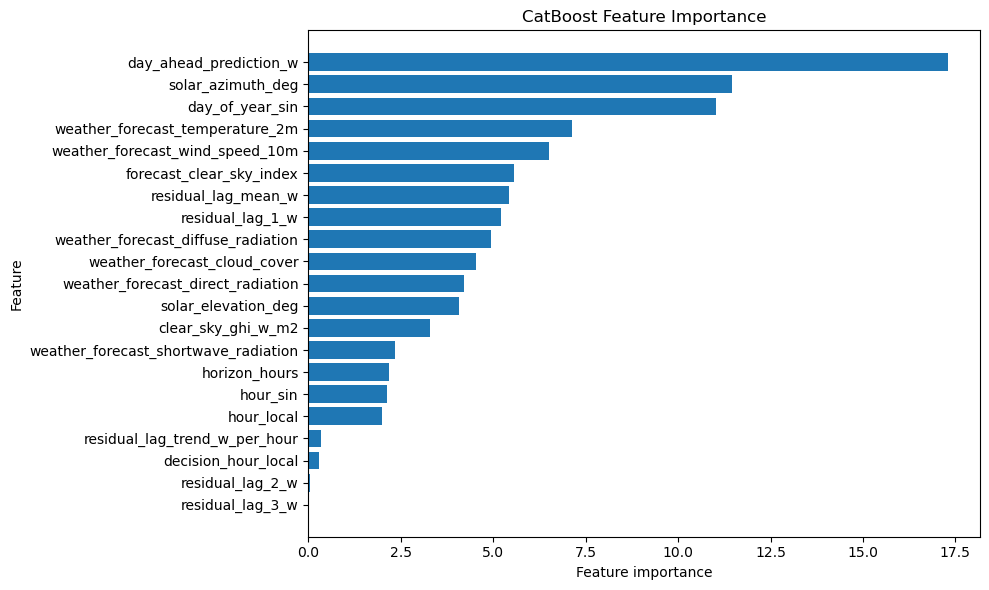

In [72]:
feature_importance = pd.DataFrame({
    "feature": residual_features,
    "importance": residual_model.get_feature_importance()
}).sort_values("importance", ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1]
)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")
plt.tight_layout()
plt.show()

In [70]:
feature_importance[feature_importance.importance<0.01].feature.values

array(['remaining_horizon_hours', 'residual_lag_3_available',
       'residual_lag_std_w'], dtype=object)

## MIMO MLP: joint intraday residual trajectory

Each row below is one MPC decision time. The inputs include only residuals and PV measurements completed **before** that time, while the model outputs the residual trajectory for all future solar-active hours. A masked loss handles shorter trajectories at the end of the solar day.

The outer folds remain whole-week splits. The day-ahead prediction is cross-fitted inside outer training, then frozen before residual trajectories are constructed. An inner whole-week fold chooses the early-stopping epoch; the final MIMO model is refitted on every outer-training week for that selected number of epochs.


In [81]:
# MIMO MLP residual trajectory experiment
from energy.modeling.pv_mimo import (
    MIMOMLPTrainingConfig,
    build_mimo_residual_samples,
    fit_mimo_residual_mlp,
    refit_config_for_selected_epoch,
    trajectory_prediction_frame,
)

# Install once in the notebook environment if needed:
# python -m pip install -e ".[train,neural]"

MIMO_N_LAGS = 4
MIMO_CONFIG = MIMOMLPTrainingConfig(
    hidden_width=48,
    hidden_layers=2,
    dropout=0.10,
    learning_rate=1e-3,
    weight_decay=1e-3,
    batch_size=64,
    max_epochs=300,
    patience=30,
    random_state=42,
)

# The maximum possible number of future active hours is fixed across
# all folds. End-of-day tails are padded and excluded by target_mask.
MIMO_MAX_HORIZON = max(
    len(day.loc[day["hour_local"] > decision_hour])
    for _, day in mpc_frame.groupby("delivery_date_local")
    for decision_hour in range(24)
    if (day["hour_local"] < decision_hour).any()
)
print(f"MIMO maximum remaining active horizon: {MIMO_MAX_HORIZON} hours")


MIMO maximum remaining active horizon: 12 hours


In [82]:
# This uses the same mpc_frame, forecast_features and
# add_day_ahead_predictions() defined in the direct-residual cells.
mimo_fold_metrics = []
mimo_lead_metrics = []
mimo_selection = []

outer_cv = SeasonalWeekKFold(n_splits=3, random_state=42)

for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(
    outer_cv.split(mpc_frame)
):
    # OOF baseline inside train; outer-train baseline applied to test.
    outer_train, outer_test = add_day_ahead_predictions(
        mpc_frame.iloc[outer_train_idx],
        mpc_frame.iloc[outer_test_idx],
        outer_fold,
    )

    mimo_train = build_mimo_residual_samples(
        outer_train,
        future_features=forecast_features,
        n_lags=MIMO_N_LAGS,
        max_horizon=MIMO_MAX_HORIZON,
    )
    mimo_test = build_mimo_residual_samples(
        outer_test,
        future_features=forecast_features,
        n_lags=MIMO_N_LAGS,
        max_horizon=MIMO_MAX_HORIZON,
    )

    # A separate, group-safe inner fold selects the epoch. All MIMO
    # decision samples from a delivery week stay on the same side.
    selection_cv = SeasonalWeekKFold(
        n_splits=3,
        random_state=10_000 + outer_fold,
    )
    selection_fold = next(selection_cv.split_with_metadata(outer_train))
    selection_train = mimo_train.select_weeks(selection_fold.train_weeks)
    selection_validation = mimo_train.select_weeks(selection_fold.test_weeks)

    selected_fit = fit_mimo_residual_mlp(
        selection_train,
        selection_validation,
        config=MIMO_CONFIG,
    )
    mimo_selection.append({
        "fold": outer_fold,
        "selected_epoch": selected_fit.best_epoch,
        "validation_mae_w": selected_fit.best_validation_mae_w,
    })

    # Refit on all outer-training weeks for exactly the selected epoch.
    final_fit = fit_mimo_residual_mlp(
        mimo_train,
        validation=None,
        config=refit_config_for_selected_epoch(
            MIMO_CONFIG,
            selected_fit.best_epoch,
        ),
    )
    mimo_rows = trajectory_prediction_frame(
        mimo_test,
        final_fit.predict_residual_w(mimo_test),
    )

    for variant, prediction in {
        "day_ahead_baseline": mimo_rows["day_ahead_prediction_w"],
        "mimo_mlp_residual": mimo_rows["mimo_prediction_w"],
    }.items():
        mimo_fold_metrics.append({
            "fold": outer_fold,
            "variant": variant,
            "mae_w": mean_absolute_error(
                mimo_rows["target_pv_power_w"], prediction
            ),
            "rmse_w": mean_squared_error(
                mimo_rows["target_pv_power_w"], prediction
            ) ** 0.5,
            "n_rows": len(mimo_rows),
        })

    for lead_hours, part in mimo_rows.groupby("lead_hours"):
        mimo_lead_metrics.append({
            "fold": outer_fold,
            "lead_hours": lead_hours,
            "baseline_mae_w": mean_absolute_error(
                part["target_pv_power_w"],
                part["day_ahead_prediction_w"],
            ),
            "mimo_mae_w": mean_absolute_error(
                part["target_pv_power_w"],
                part["mimo_prediction_w"],
            ),
            "n_rows": len(part),
        })

mimo_fold_metrics = pd.DataFrame(mimo_fold_metrics)
mimo_lead_metrics = pd.DataFrame(mimo_lead_metrics)
mimo_selection = pd.DataFrame(mimo_selection)

print("\nMIMO MLP selected epochs:")
print(mimo_selection.round(2))

print("\nMIMO solar-active MPC trajectory metrics:")
print(
    mimo_fold_metrics
    .groupby("variant")[["mae_w", "rmse_w"]]
    .agg(["mean", "std"])
    .round(2)
)

print("\nMIMO MAE by remaining horizon:")
print(
    mimo_lead_metrics
    .groupby("lead_hours")[["baseline_mae_w", "mimo_mae_w"]]
    .mean()
    .round(2)
)



MIMO MLP selected epochs:
   fold  selected_epoch  validation_mae_w
0     0               8             19.01
1     1               6             16.62
2     2               6             19.50

MIMO solar-active MPC trajectory metrics:
                    mae_w       rmse_w      
                     mean   std   mean   std
variant                                     
day_ahead_baseline  18.07  1.08  34.05  2.21
mimo_mlp_residual   17.39  0.56  33.00  1.41

MIMO MAE by remaining horizon:
            baseline_mae_w  mimo_mae_w
lead_hours                            
1                    30.64       28.51
2                    24.89       23.75
3                    19.76       19.37
4                    15.26       14.97
5                    11.50       11.40
6                     9.85        9.84
7                     8.89        8.83
8                     8.05        8.00
9                     6.95        7.23
10                    6.00        6.10
11                    4.62        4.9

In [ ]:
1                    30.64           29.03
2                    24.89           24.39
3                    19.76           19.46
4                    15.26           15.06
5                    11.50           11.43
6                     9.85            9.68
7                     8.89            8.60
8                     8.05            7.58
9                     6.95            6.28
10                    6.00            5.22
11                    4.62            4.00
12                    3.46            2.78

## Encoder–decoder LSTM MIMO comparison

This model uses exactly the MIMO data contract above. An LSTM encoder reads the chronological sequence of completed actual PV, frozen day-ahead PV, and residual values. An LSTM decoder then reads the known future trajectory of day-ahead PV, forecast weather, calendar features, and solar geometry. It does not use teacher forcing or future actual PV values.


In [ ]:
# Encoder-decoder LSTM MIMO residual trajectory experiment
from energy.modeling.pv_mimo import (
    MIMOLSTMTrainingConfig,
    build_lstm_sequence_samples,
    fit_mimo_residual_lstm,
    refit_lstm_config_for_selected_epoch,
)

LSTM_N_LAGS = 4
LSTM_CONFIG = MIMOLSTMTrainingConfig(
    hidden_size=24,
    num_layers=1,
    dropout=0.10,
    learning_rate=1e-3,
    weight_decay=1e-3,
    batch_size=256,
    max_epochs=150,
    patience=20,
    random_state=42,
)

LSTM_MAX_HORIZON = max(
    len(day.loc[day["hour_local"] > decision_hour])
    for _, day in mpc_frame.groupby("delivery_date_local")
    for decision_hour in range(24)
    if (day["hour_local"] < decision_hour).any()
)

lstm_fold_metrics = []
lstm_lead_metrics = []
lstm_selection = []
outer_cv = SeasonalWeekKFold(n_splits=3, random_state=42)

for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(
    outer_cv.split(mpc_frame)
):
    outer_train, outer_test = add_day_ahead_predictions(
        mpc_frame.iloc[outer_train_idx],
        mpc_frame.iloc[outer_test_idx],
        outer_fold,
    )

    # The MIMO sample builder creates the same frozen baseline and
    # target-mask contract used by the MLP above.
    mimo_train = build_mimo_residual_samples(
        outer_train,
        future_features=forecast_features,
        n_lags=LSTM_N_LAGS,
        max_horizon=LSTM_MAX_HORIZON,
    )
    mimo_test = build_mimo_residual_samples(
        outer_test,
        future_features=forecast_features,
        n_lags=LSTM_N_LAGS,
        max_horizon=LSTM_MAX_HORIZON,
    )
    lstm_train = build_lstm_sequence_samples(
        mimo_train,
        future_features=forecast_features,
        n_lags=LSTM_N_LAGS,
    )
    lstm_test = build_lstm_sequence_samples(
        mimo_test,
        future_features=forecast_features,
        n_lags=LSTM_N_LAGS,
    )

    selection_cv = SeasonalWeekKFold(
        n_splits=3,
        random_state=10_000 + outer_fold,
    )
    selection_fold = next(selection_cv.split_with_metadata(outer_train))
    selected_fit = fit_mimo_residual_lstm(
        lstm_train.select_weeks(selection_fold.train_weeks),
        lstm_train.select_weeks(selection_fold.test_weeks),
        config=LSTM_CONFIG,
    )
    lstm_selection.append({
        "fold": outer_fold,
        "selected_epoch": selected_fit.best_epoch,
        "validation_mae_w": selected_fit.best_validation_mae_w,
    })

    # Refit on all outer-training weeks for the selected epoch.
    final_fit = fit_mimo_residual_lstm(
        lstm_train,
        validation=None,
        config=refit_lstm_config_for_selected_epoch(
            LSTM_CONFIG,
            selected_fit.best_epoch,
        ),
    )
    lstm_rows = trajectory_prediction_frame(
        lstm_test.trajectory,
        final_fit.predict_residual_w(lstm_test),
    )

    for variant, prediction in {
        "day_ahead_baseline": lstm_rows["day_ahead_prediction_w"],
        "mimo_lstm_residual": lstm_rows["mimo_prediction_w"],
    }.items():
        lstm_fold_metrics.append({
            "fold": outer_fold,
            "variant": variant,
            "mae_w": mean_absolute_error(
                lstm_rows["target_pv_power_w"], prediction
            ),
            "rmse_w": mean_squared_error(
                lstm_rows["target_pv_power_w"], prediction
            ) ** 0.5,
            "n_rows": len(lstm_rows),
        })

    for lead_hours, part in lstm_rows.groupby("lead_hours"):
        lstm_lead_metrics.append({
            "fold": outer_fold,
            "lead_hours": lead_hours,
            "baseline_mae_w": mean_absolute_error(
                part["target_pv_power_w"],
                part["day_ahead_prediction_w"],
            ),
            "lstm_mae_w": mean_absolute_error(
                part["target_pv_power_w"],
                part["mimo_prediction_w"],
            ),
            "n_rows": len(part),
        })

lstm_fold_metrics = pd.DataFrame(lstm_fold_metrics)
lstm_lead_metrics = pd.DataFrame(lstm_lead_metrics)
lstm_selection = pd.DataFrame(lstm_selection)

print("\nLSTM selected epochs:")
print(lstm_selection.round(2))
print("\nLSTM solar-active MPC trajectory metrics:")
print(
    lstm_fold_metrics
    .groupby("variant")[["mae_w", "rmse_w"]]
    .agg(["mean", "std"])
    .round(2)
)
print("\nLSTM MAE by remaining horizon:")
print(
    lstm_lead_metrics
    .groupby("lead_hours")[["baseline_mae_w", "lstm_mae_w"]]
    .mean()
    .round(2)
)
